<a href="https://colab.research.google.com/github/Sudeshnachitrala/-AIDriven-Archaeological-Site-Mapping/blob/main/soil_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Soil detection.v3i.yolov11.zip to Soil detection.v3i.yolov11.zip


In [6]:
!unzip -q "Soil detection.v3i.yolov11.zip" -d /content/


replace /content/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [8]:
!ls /content


 data.yaml	       sample_data			 train
 README.dataset.txt   'Soil detection.v3i.yolov11.zip'	 valid
 README.roboflow.txt   test


In [10]:
!pip install --upgrade pip
!pip install ultralytics opencv-python --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [11]:
import ultralytics
ultralytics.checks()


Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.5/112.6 GB disk)


In [14]:
from ultralytics import YOLO


In [15]:
model = YOLO("yolo11n.pt")  # or yolo11s.pt

model.train(
    data="/content/data.yaml",  # your dataset path
    epochs=100,
    imgsz=640,
    batch=16,
    name="soil_yolov11_train"
)


Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=soil_yolov11_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6582d91040>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [17]:
"/content/runs/detect/soil_yolov11_train/"


'/content/runs/detect/soil_yolov11_train/'

In [18]:
!ls '/content/runs/detect/soil_yolov11_train'


args.yaml			 labels.jpg	      train_batch1.jpg
BoxF1_curve.png			 results.csv	      train_batch2.jpg
BoxP_curve.png			 results.png	      val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg     val_batch0_pred.jpg
BoxR_curve.png			 train_batch1170.jpg  val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch1171.jpg  val_batch1_pred.jpg
confusion_matrix.png		 train_batch1172.jpg  weights


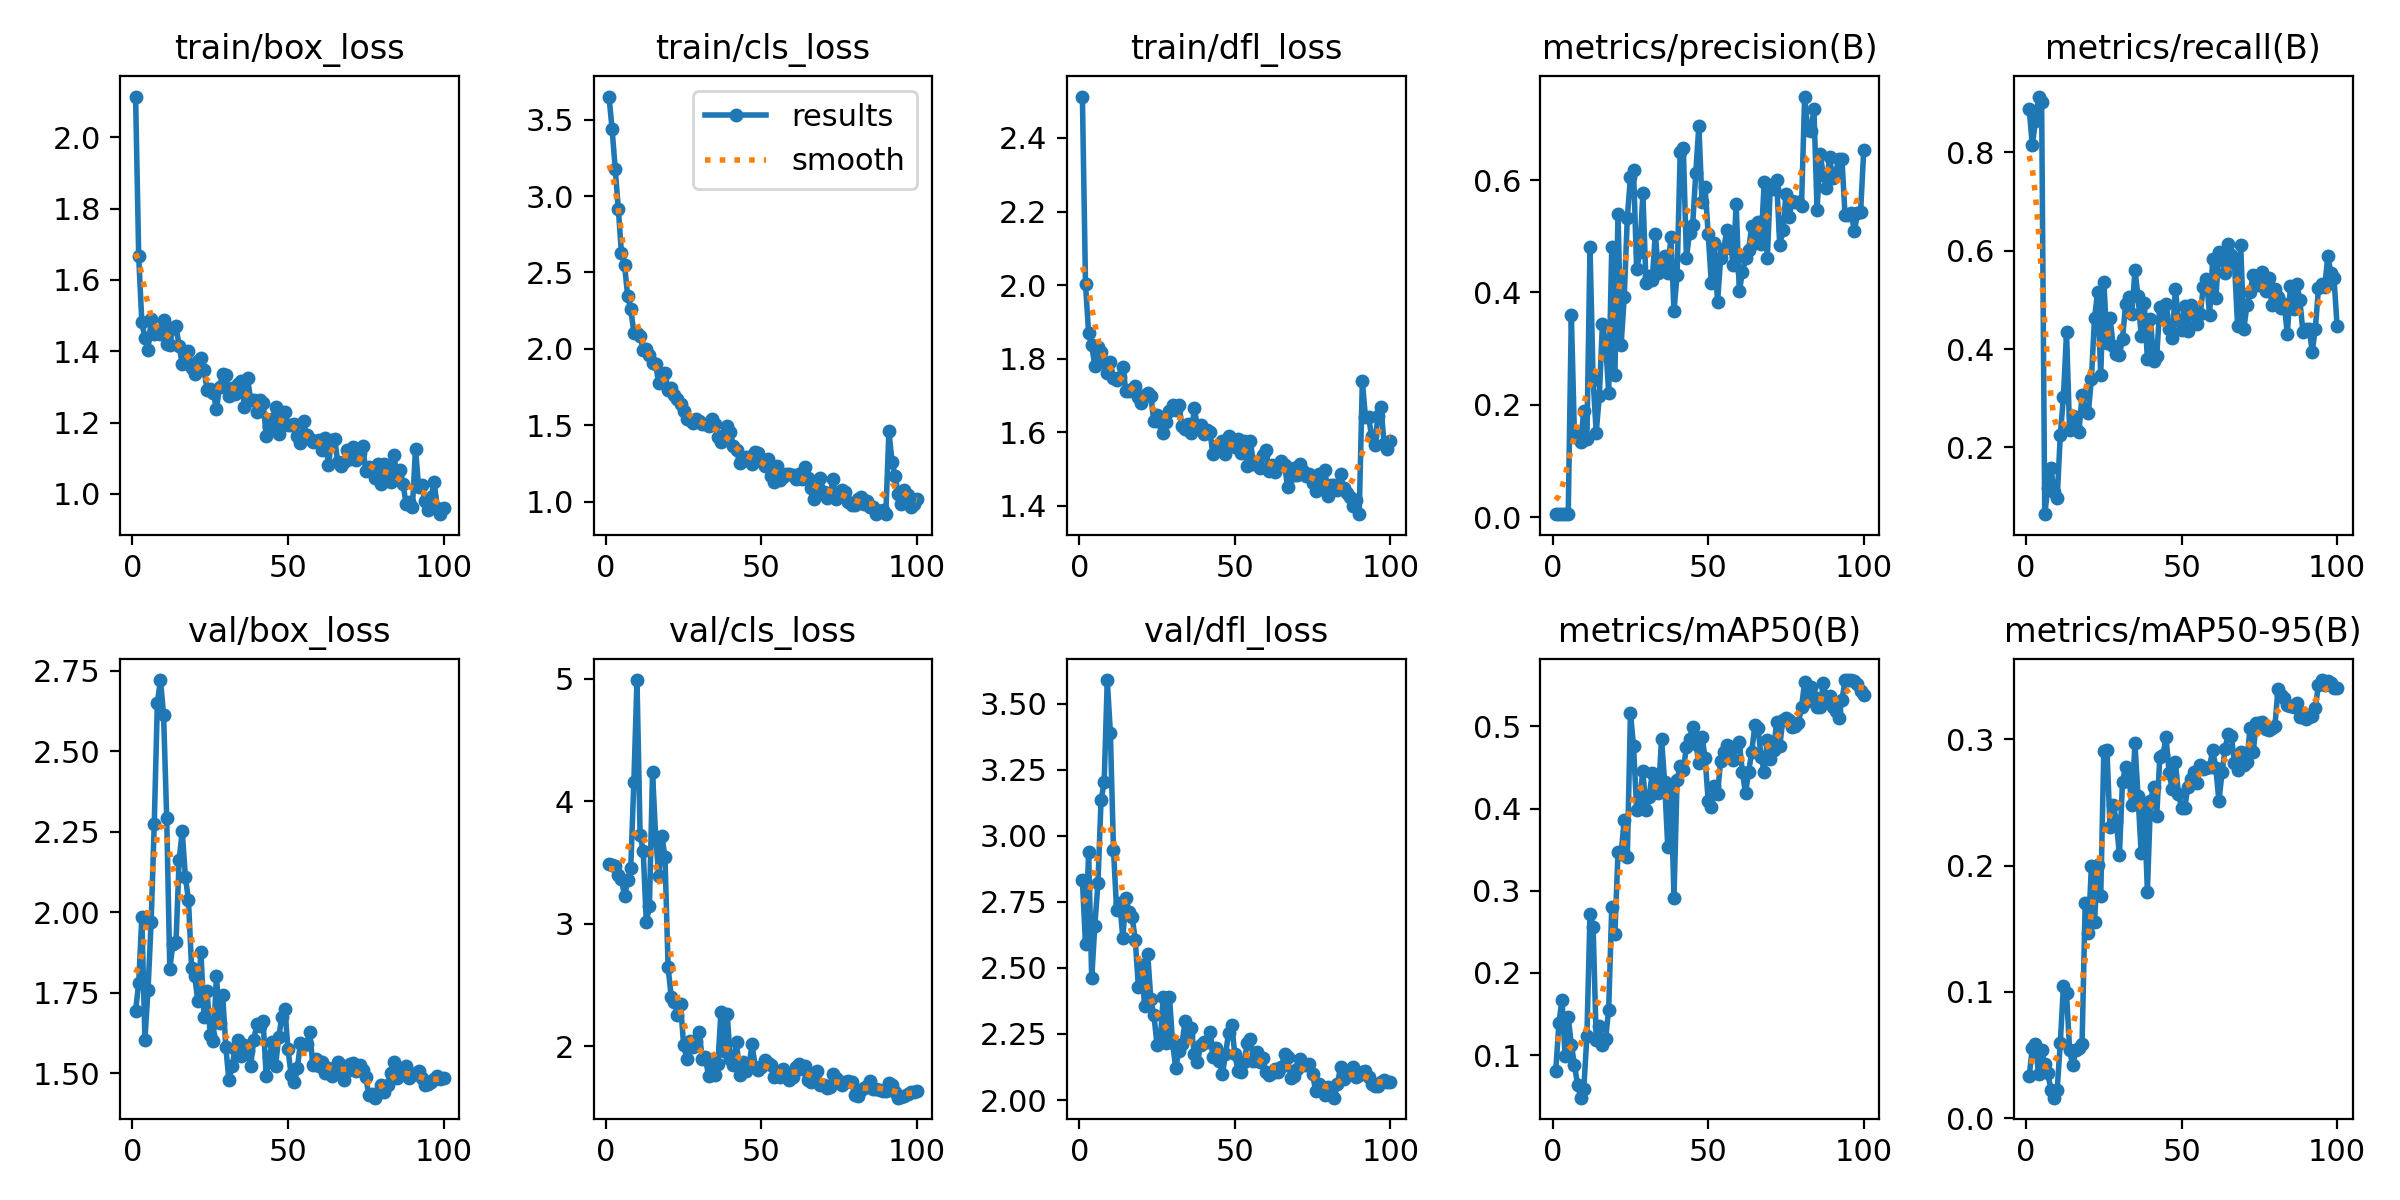

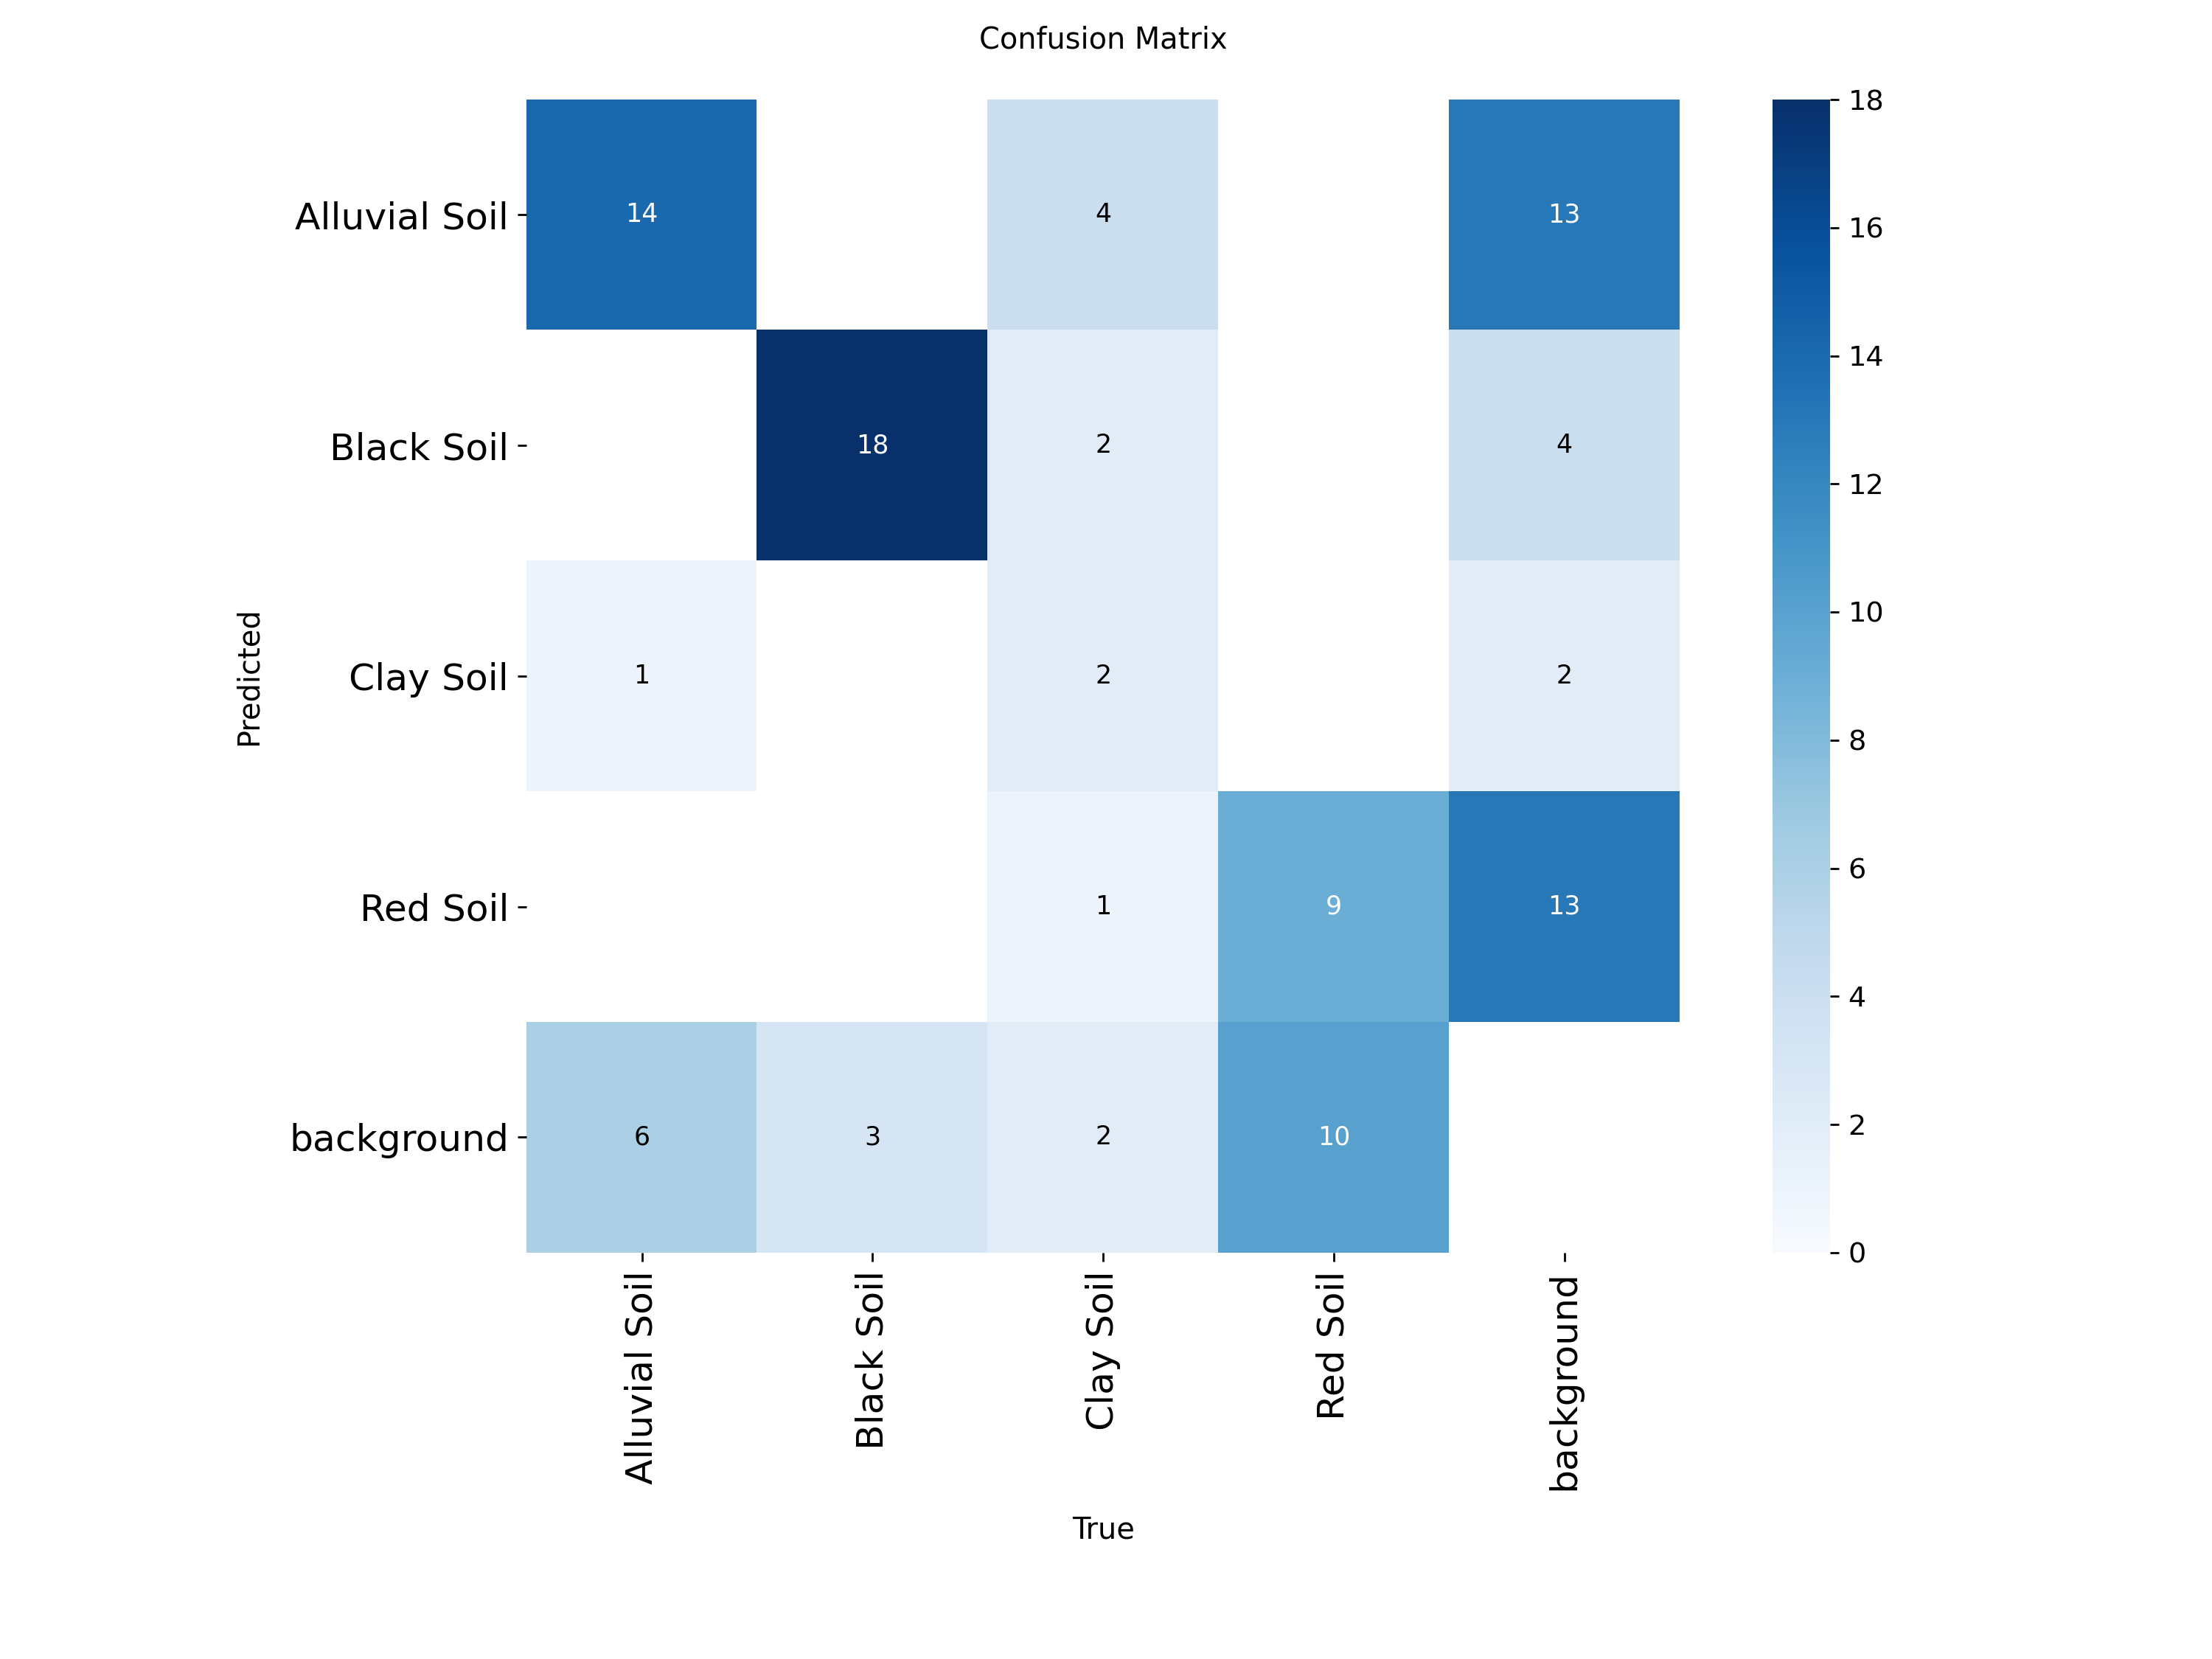

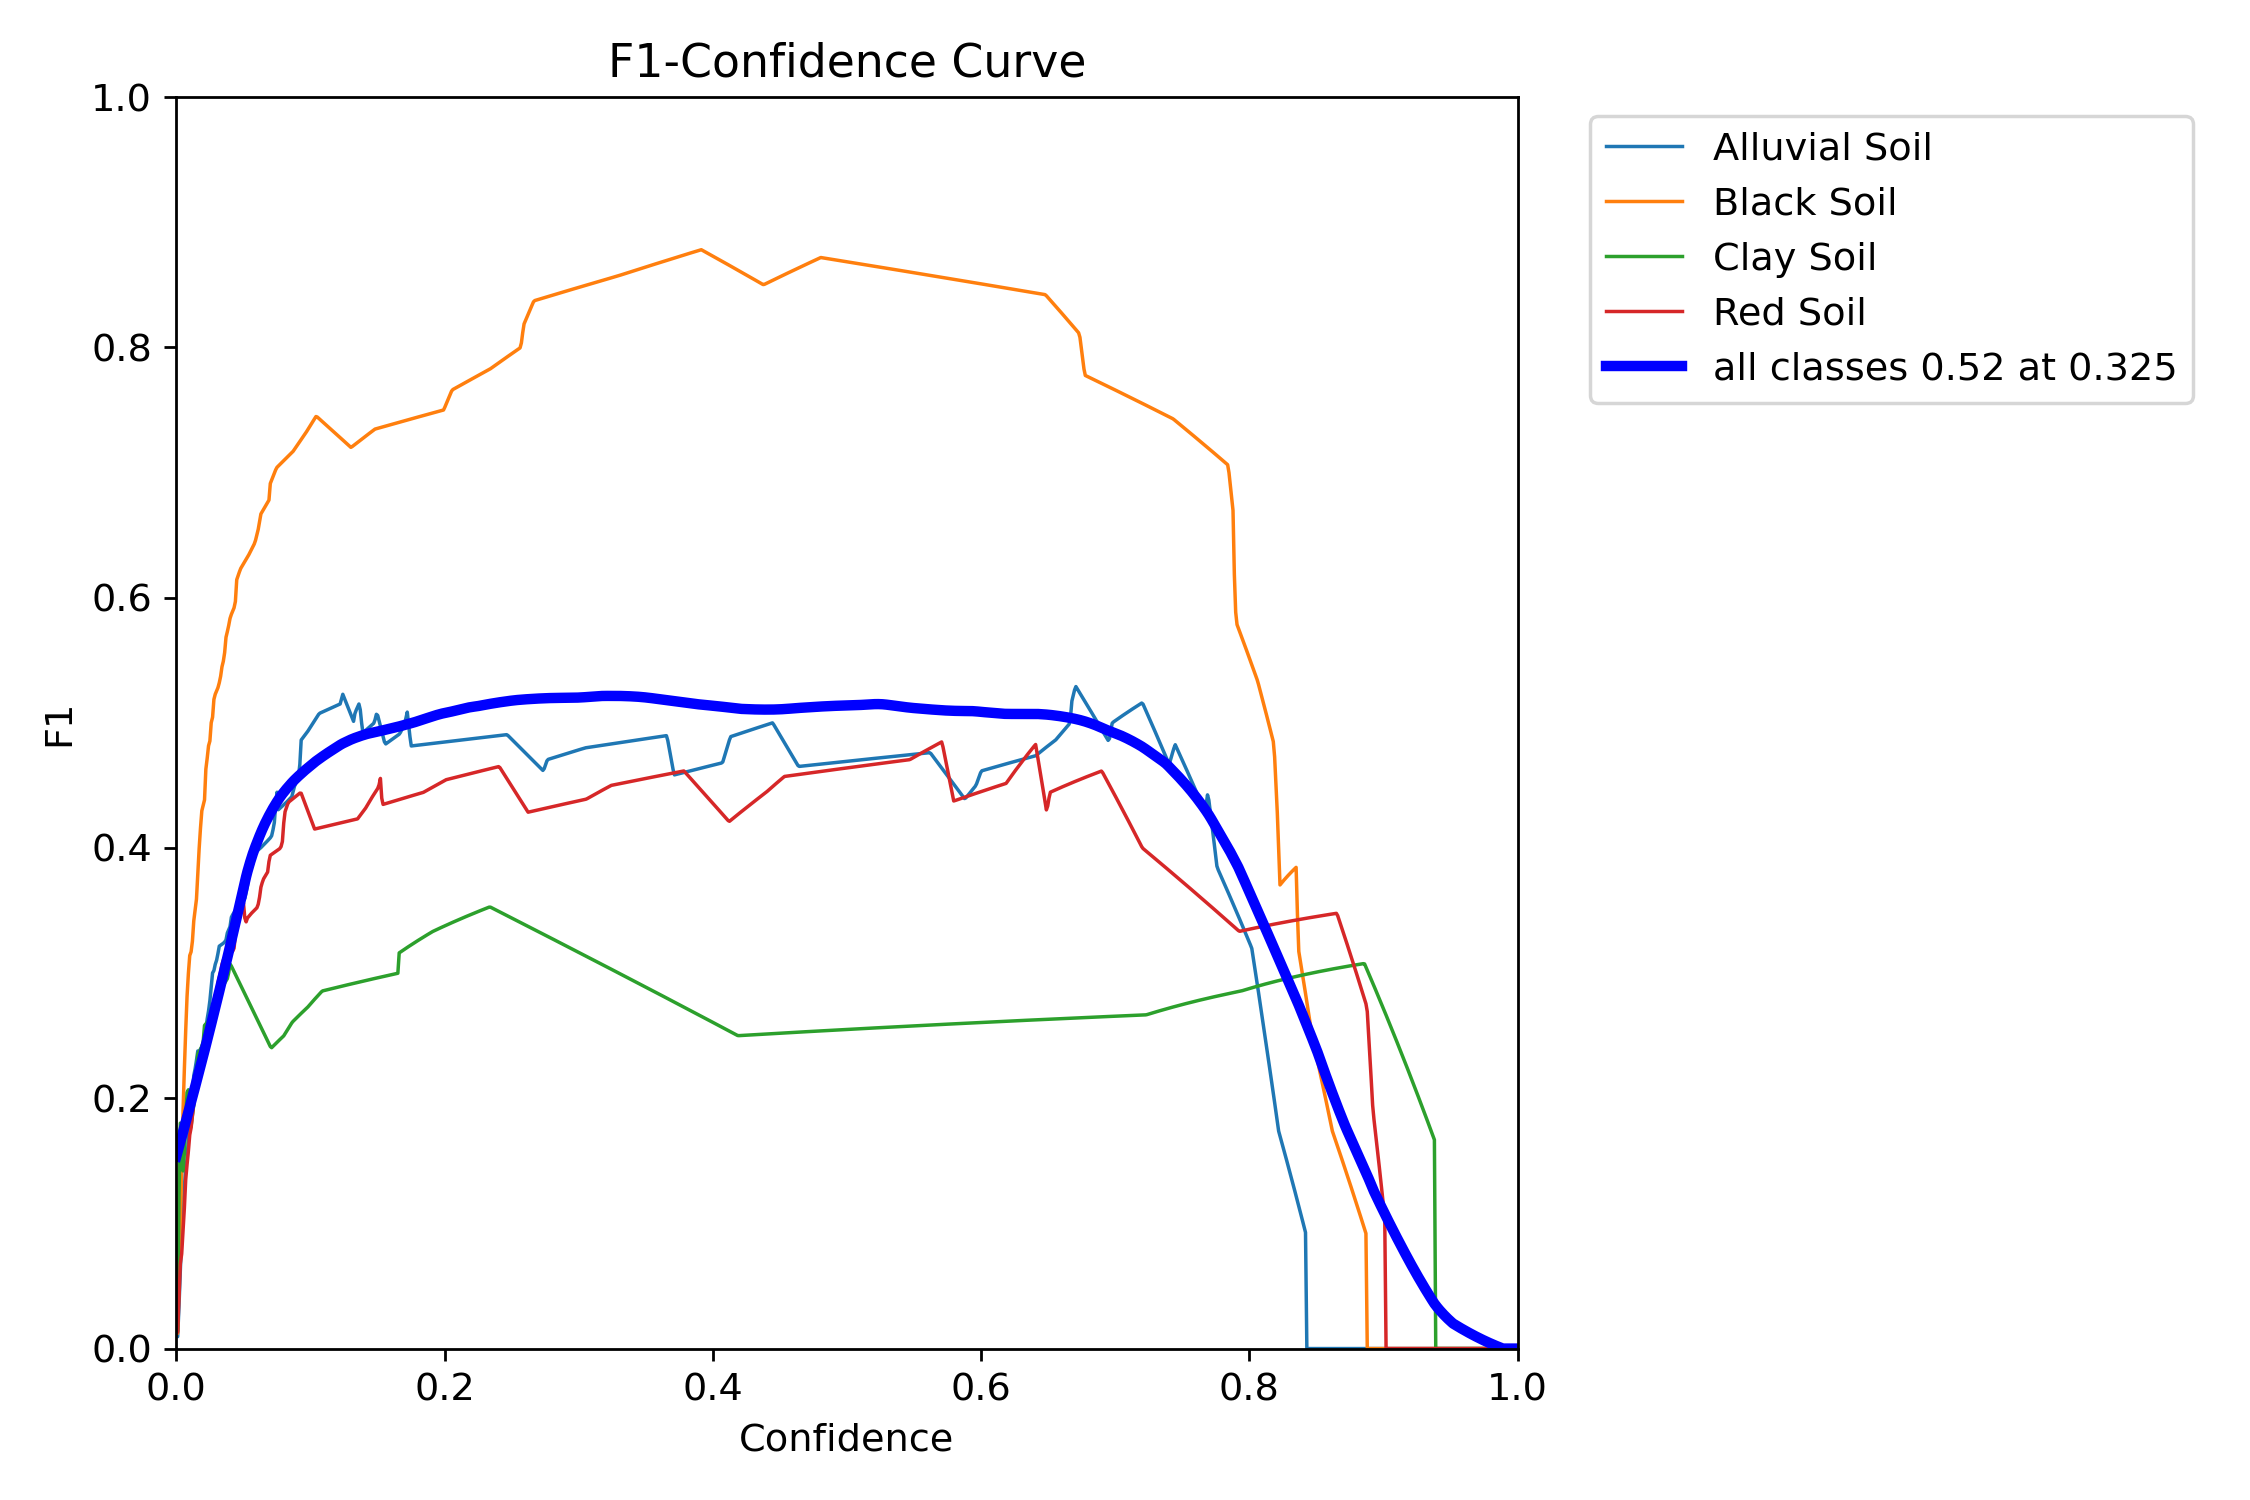

In [19]:
from IPython.display import Image, display

resultData = '/content/runs/detect/soil_yolov11_train'

# Training curves
display(Image(filename=f'{resultData}/results.png'))

# Confusion matrix
display(Image(filename=f'{resultData}/confusion_matrix.png'))

# F1-score curve
display(Image(filename=f'{resultData}/BoxF1_curve.png'))


In [20]:
precision = 0.635
recall = 0.646

f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")


Precision: 0.6350
Recall:    0.6460
F1 Score:  0.6405


In [21]:
import pandas as pd

df = pd.read_csv(f'{resultData}/results.csv')
print(df.tail(1))  # Last row = final epoch metrics


    epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  \
99    100  436.46         0.96167         1.01683          1.5762   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
99               0.65301            0.44588            0.5385   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
99              0.34073        1.4863       1.63008       2.06876  0.000025   

      lr/pg1    lr/pg2  
99  0.000025  0.000025  


In [22]:
ROOT_DIR = "/content"  # Replace if your data.yaml is elsewhere

!yolo task=detect mode=val \
  model="/content/runs/detect/soil_yolov11_train/weights/best.pt" \
  data="{ROOT_DIR}/data.yaml"


Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1853.6±436.4 MB/s, size: 100.6 KB)
val: Scanning /content/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 841.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1it/s 1.9s
                   all         58         72      0.538      0.532      0.556      0.347
         Alluvial Soil         18         21      0.419      0.571      0.583      0.313
            Black Soil         17         21      0.856      0.857       0.85      0.542
             Clay Soil          9         11      0.449      0.227      0.313      0.203
              Red Soil         15         19      0.429      0.474      0.477      0.329
Speed: 8.1ms preprocess, 8.7ms inference, 0.0ms loss, 3.1

In [23]:
!yolo task=detect mode=predict \
  model="/content/runs/detect/soil_yolov11_train/weights/best.pt" \
  conf=0.25 \
  source="{ROOT_DIR}/test/images"


Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

image 1/28 /content/test/images/Black_38_jpg.rf.cce2afe5e739cb1d77fbdfd7d51d5012.jpg: 640x640 1 Black Soil, 8.9ms
image 2/28 /content/test/images/Black_44_jpg.rf.bfb078e5b0304edb36b2cc1d57ea3cbc.jpg: 640x640 1 Black Soil, 8.0ms
image 3/28 /content/test/images/Black_47_jpg.rf.30fa0ac078480d4fbb2bdb6bd4c189c3.jpg: 640x640 1 Black Soil, 7.9ms
image 4/28 /content/test/images/Clay_47_jpg.rf.75ea8b632fb8f5e1a540b31945d9ff4d.jpg: 640x640 1 Clay Soil, 7.9ms
image 5/28 /content/test/images/Copy-of-clay-soil-cropped_jpg.rf.9dfcef24065c2fa79a282f89bff22b80.jpg: 640x640 1 Clay Soil, 7.9ms
image 6/28 /content/test/images/Copy-of-image14_jpeg.rf.4e376475395c1adc2faba2ce470bf93e.jpg: 640x640 1 Red Soil, 7.9ms
image 7/28 /content/test/images/Copy-of-image15_jpeg.rf.4dcea00f6cf966d634e331ab311cbdca.jpg: 640x640 1 Clay Soil, 1 Red Soil, 7.

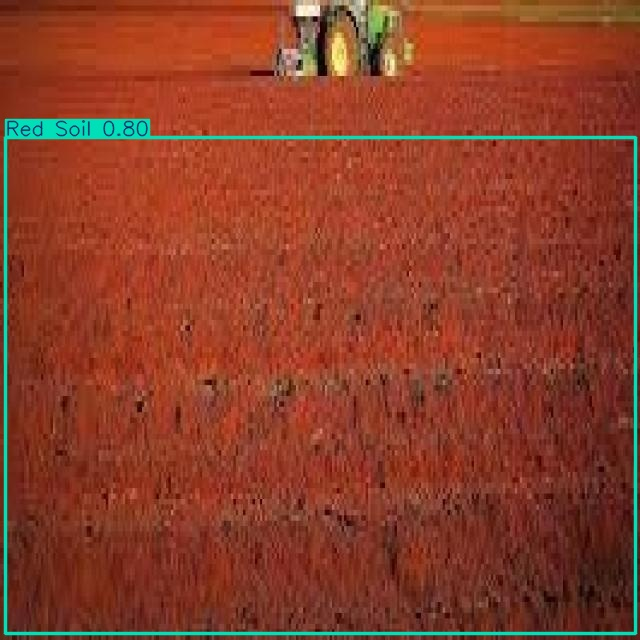

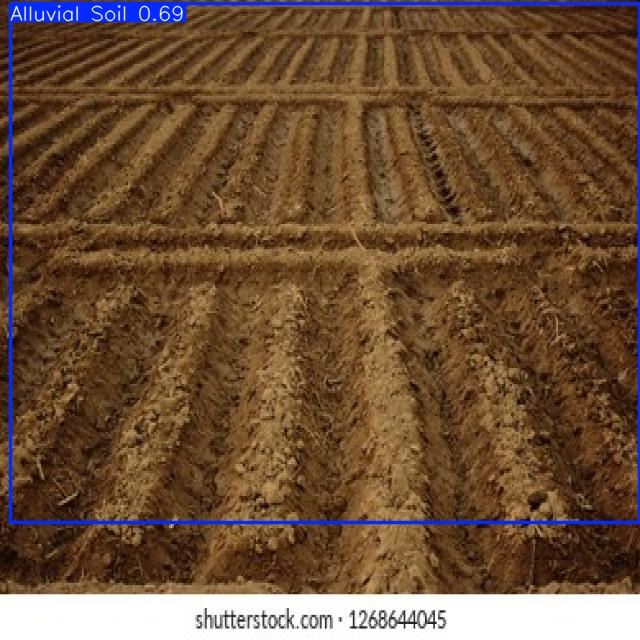

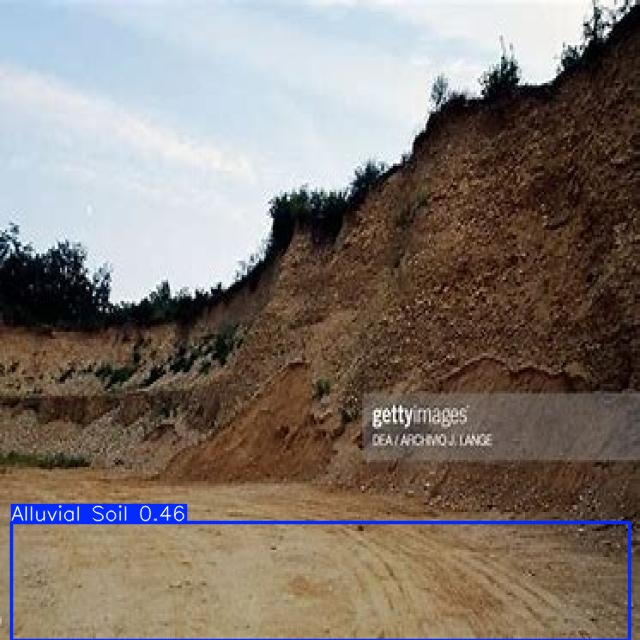

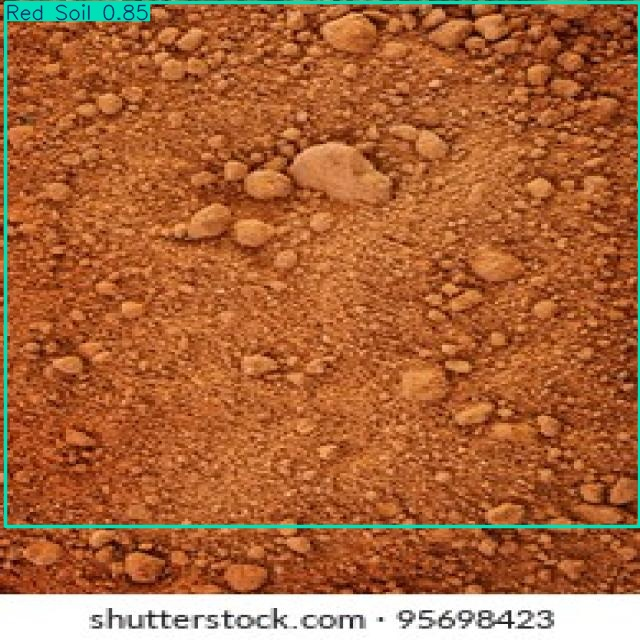

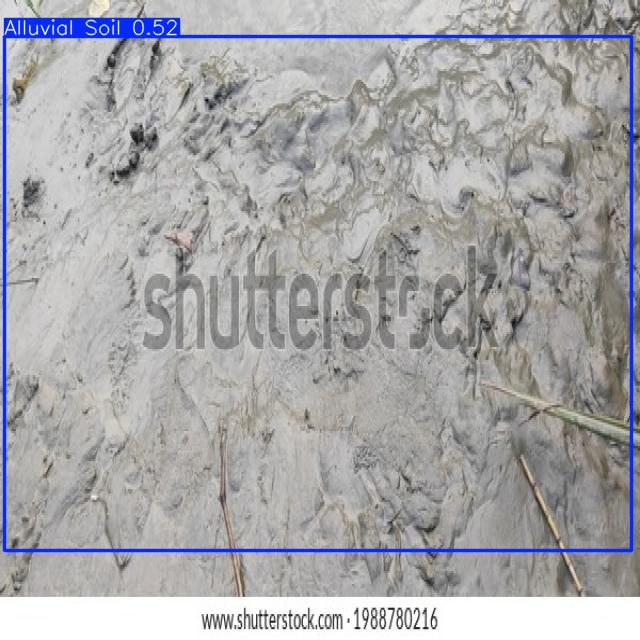

In [25]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict/*.jpg')[:5]:
    display(Image(filename=image_path, height=600))


In [26]:
model.export(format="onnx")        # for ONNX
model.export(format="torchscript") # for TorchScript
model.export(format="coreml")      # for CoreML (iOS)


Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/soil_yolov11_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 7.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 9.6s, saved as '/content/runs/detect/soil_yolov11_train/weights/best.onnx' (10.1 MB)

Export complete (10.0s)
Results saved to /content/runs/detect/soil_y

/usr/local/lib/python3.12/dist-packages/coremltools/optimize/torch/palettization/fake_palettize.py:82: SyntaxWarning: invalid escape sequence '\_'
  n_bits (:obj:`int`): Number of palettization bits. There would be :math:`2^{n\_bits}` unique weights in the ``LUT``.



CoreML: starting export with coremltools 9.0b1...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 89.85 passes/s]


CoreML: export success ✅ 13.7s, saved as '/content/runs/detect/soil_yolov11_train/weights/best.mlpackage' (5.1 MB)

Export complete (14.1s)
Results saved to /content/runs/detect/soil_yolov11_train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/soil_yolov11_train/weights/best.mlpackage imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/soil_yolov11_train/weights/best.mlpackage imgsz=640 data=/content/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/soil_yolov11_train/weights/best.mlpackage'